**Stock Price Prediction with LSTM:**

In [2]:
# 1. Install Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import drive
import zipfile
import os

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import joblib

import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import drive
import zipfile
import os

# 2. Load and Preprocess the Dataset
drive.mount('/content/drive')

DATA_ZIP = Path("/content/drive/MyDrive/stocks.zip")

with zipfile.ZipFile(DATA_ZIP, 'r') as zip_ref:
    zip_ref.extractall('/content')

print(os.listdir('/content'))

DATA_PATH = '/content/stocks/AAPL.csv'
df = pd.read_csv(DATA_PATH)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['.config', 'stocks', 'symbols_valid_meta.csv', 'etfs', 'drive', 'sample_data']


,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [6]:
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

df['Target'] = df['Close'].shift(-1)
df = df.dropna()

In [7]:
# 3. Prepare the Dataset for Training
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

In [8]:
def create_sequences(data, seq_length=30):
    X = []
    y = []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, :-1])  # excl. Target
        y.append(data[i+seq_length, -1])     # Target

    return np.array(X), np.array(y)

X, y = create_sequences(scaled_df.values, 30)

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, shuffle=False)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(6913, 30, 5)
(1482, 30, 5)
(1482, 30, 5)


In [11]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [14]:
train_dataset = StockDataset(X_train, y_train)
val_dataset = StockDataset(X_val, y_val)
test_dataset = StockDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [16]:
# 4. Define the LSTM Model
class StockGRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(StockGRUModel, self).__init__()

        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        gru_out, hidden = self.gru(x)

        last_output = gru_out[:, -1, :]

        out = self.dropout(last_output)
        out = self.fc(out)

        return out

In [17]:
input_size = X_train.shape[2]
model = StockGRUModel(input_size=input_size)
print(model)

StockGRUModel(
  (gru): GRU(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [19]:
# 5. Train the Model

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 20

train_losses = []
val_losses = []

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        predictions = model(X_batch).squeeze()
        loss = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            predictions = model(X_batch).squeeze()
            loss = criterion(predictions, y_batch)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {avg_train_loss:.6f} | "
          f"Validation Loss: {avg_val_loss:.6f}")

Epoch 1/20 | Train Loss: 0.000120 | Validation Loss: 0.011066
Epoch 2/20 | Train Loss: 0.000063 | Validation Loss: 0.009191
Epoch 3/20 | Train Loss: 0.000068 | Validation Loss: 0.011619
Epoch 4/20 | Train Loss: 0.000087 | Validation Loss: 0.010705
Epoch 5/20 | Train Loss: 0.000090 | Validation Loss: 0.010058
Epoch 6/20 | Train Loss: 0.000086 | Validation Loss: 0.010572
Epoch 7/20 | Train Loss: 0.000090 | Validation Loss: 0.008266
Epoch 8/20 | Train Loss: 0.000095 | Validation Loss: 0.010157
Epoch 9/20 | Train Loss: 0.000093 | Validation Loss: 0.009417
Epoch 10/20 | Train Loss: 0.000111 | Validation Loss: 0.008500
Epoch 11/20 | Train Loss: 0.000101 | Validation Loss: 0.009204
Epoch 12/20 | Train Loss: 0.000090 | Validation Loss: 0.009199
Epoch 13/20 | Train Loss: 0.000085 | Validation Loss: 0.008609
Epoch 14/20 | Train Loss: 0.000097 | Validation Loss: 0.009480
Epoch 15/20 | Train Loss: 0.000091 | Validation Loss: 0.007584
Epoch 16/20 | Train Loss: 0.000090 | Validation Loss: 0.007042
E

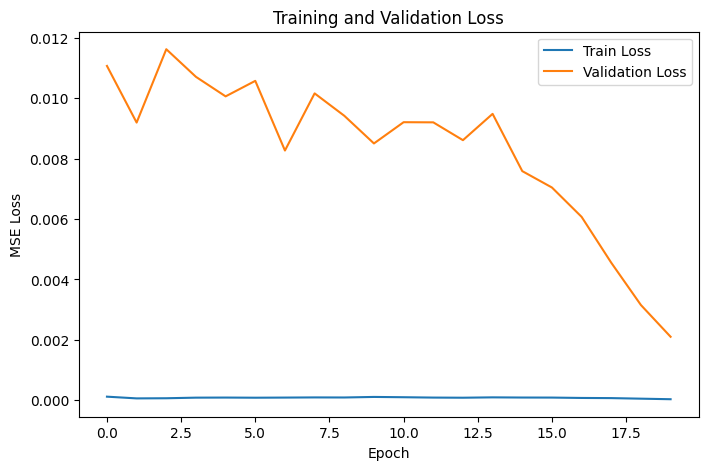

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

The model was trained using the Adam optimizer and Mean Squared Error loss function.
During each epoch, the model learned from the training data and was evaluated on the validation data.
Training and validation losses were saved and plotted to monitor the learning process.

In [21]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        predictions = model(X_batch).squeeze()

        y_true.extend(y_batch.numpy())
        y_pred.extend(predictions.numpy())

# R² score
r2 = r2_score(y_true, y_pred)
print(f"R² Score: {r2:.4f}")

R² Score: -0.5829


In [22]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

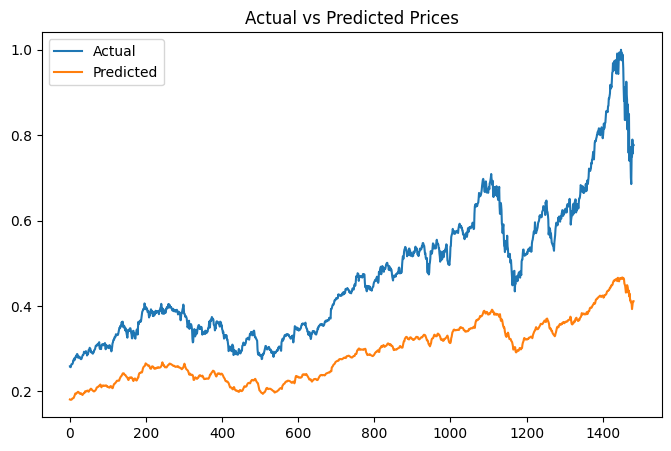

In [23]:
plt.figure(figsize=(8,5))
plt.plot(y_true, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.show()

The model achieved a low R² score, indicating that it struggled to accurately predict stock prices.
This may be due to the complexity and noise in financial time series data.
Further improvements such as better scaling, tuning hyperparameters and using more advanced architectures could improve performance.